**Import packages and dependecies**

In [ ]:
%pip install -q -e ..

In [8]:
import numpy as np
import warnings
import matplotlib.pyplot as plt
from fda.basis import BSplineBasis

warnings.filterwarnings("ignore")

### 1. Plotting B-Splines Basis of Different Degrees

**Example 1:**

In [9]:
# 1. Setup parameters
domain = (0, 15)
n_basis = 6
degree = 4

# 2. Initialize the basis class
basis = BSplineBasis(domain_range=domain, n_basis=n_basis, degree=degree)

# 3. Create evaluation points
x_array = np.linspace(domain[0], domain[1], 10)

# Show knot values
print("\nKnots:")
print("-"*100)
print(f"{basis.knots}")

# 4. Evaluate all basis functions
basis_matrix = basis.evaluate(x_array)
print("\nEvaluated basis values:")
print("-"*100)
print(f"{basis_matrix}")

# 5. Calculate derivatives
derivatives_order1 = basis.evaluate_derivative(eval_points=x_array, order=1)
derivatives_order2 = basis.evaluate_derivative(eval_points=x_array, order=2)

print("\nOrder 1 Derivatives:")
print("-"*100)
print(f"{derivatives_order1}")

print("\nOrder 2 Derivatives:")
print("-"*100)
print(f"{derivatives_order2}")



Knots:
----------------------------------------------------------------------------------------------------
[ 0.   0.   0.   0.   0.   7.5 15.  15.  15.  15.  15. ]

Evaluated basis values:
----------------------------------------------------------------------------------------------------
[[1.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00]
 [3.65950312e-01 5.16689529e-01 1.07605548e-01 9.44977900e-03
  3.04831581e-04 0.00000000e+00]
 [9.52598689e-02 5.41380887e-01 2.95076970e-01 6.34049688e-02
  4.87730529e-03 0.00000000e+00]
 [1.23456790e-02 3.70370370e-01 4.19753086e-01 1.72839506e-01
  2.46913580e-02 0.00000000e+00]
 [1.52415790e-04 1.90214906e-01 4.19448255e-01 3.12147538e-01
  7.80368846e-02 0.00000000e+00]
 [0.00000000e+00 7.80368846e-02 3.12147538e-01 4.19448255e-01
  1.90214906e-01 1.52415790e-04]
 [0.00000000e+00 2.46913580e-02 1.72839506e-01 4.19753086e-01
  3.70370370e-01 1.23456790e-02]
 [0.00000000e+00 4.87730529e-03 6.34049688e

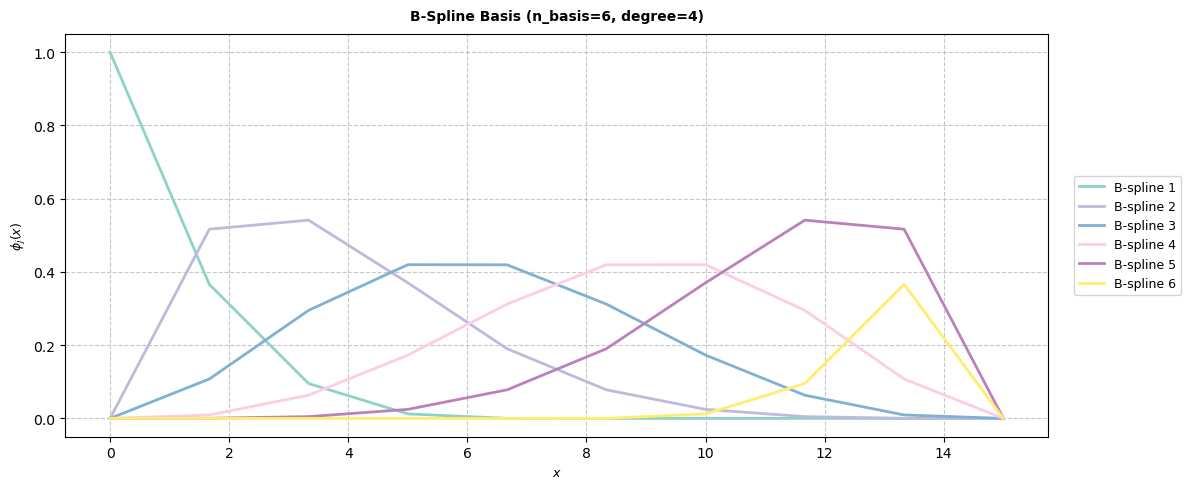

In [10]:
# 5. Create a plot of the B-splines
basis.plot_b_spline(x_array)

**Example 2**

In [11]:
# 1. Setup parameters
domain = (0, 15)
n_basis = 3
degree = 0

# 2. Initialize the basis class
basis = BSplineBasis(domain_range=domain, n_basis=n_basis, degree=degree)

# 3. Create evaluation points
x_array = np.linspace(domain[0], domain[1], 10)

# Show knot values
print("\nKnots:")
print("-"*100)
print(f"{basis.knots}")

# 4. Evaluate all basis functions
basis_matrix = basis.evaluate(x_array)
print("\nEvaluated basis values:")
print("-"*100)
print(f"{basis_matrix}")

# 5. Calculate derivatives
derivatives_order1 = basis.evaluate_derivative(eval_points=x_array, order=1)
derivatives_order2 = basis.evaluate_derivative(eval_points=x_array, order=2)

print("\nOrder 1 Derivatives:")
print("-"*100)
print(f"{derivatives_order1}")

print("\nOrder 2 Derivatives:")
print("-"*100)
print(f"{derivatives_order2}")


Knots:
----------------------------------------------------------------------------------------------------
[ 0.  5. 10. 15.]

Evaluated basis values:
----------------------------------------------------------------------------------------------------
[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]]

Order 1 Derivatives:
----------------------------------------------------------------------------------------------------
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]

Order 2 Derivatives:
----------------------------------------------------------------------------------------------------
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


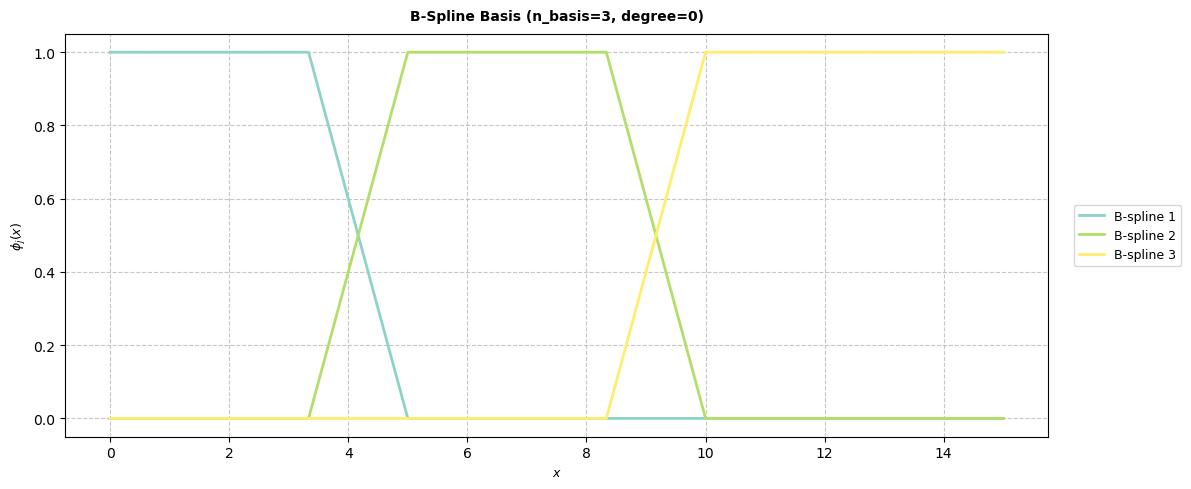

In [12]:
# 5. Create a plot of the B-splines
basis.plot_b_spline(x_array)

### 2. Comparing Different Weighting Methods for B-Splines

In [13]:
# 1. Setup parameters
domain = (0, 15)
n_basis = 4
degree = 3
weight_type_list = ["trigonometric", "hyperbolic", "variable_degree"]

# 2. Create evaluation points
x_array = np.linspace(domain[0], domain[1], 10)

# 3. Create a function p(x) to use for variable_degree weighting
def smooth_sigmoid_degree_func(x: np.ndarray) -> np.ndarray:
    """
    Uses a logistic curve to smoothly transition from degree 1.0 to 3.0,
    centered at x = 5.0 with a growth rate parameter.
    """
    center = 5.0
    growth_rate = 2.0  # Controls how steep the transition is
    p_min = 1.0
    p_max = 3.0
    
    # Standard logistic formula
    sigmoid = 1.0 / (1.0 + np.exp(-growth_rate * (x - center)))
    
    # Scale to the target degree range
    p_x = p_min + sigmoid * (p_max - p_min)
    return p_x

for weight_type in weight_type_list:

    print(f"\nWEIGHT TYPE: {weight_type.upper()}")
    print("-"*100)

    # 4. Initialize the basis class
    if weight_type == "variable_degree":
        p_func=smooth_sigmoid_degree_func
    else: 
        p_func=None
    basis = BSplineBasis(domain_range=domain, n_basis=n_basis, degree=degree, weight_type=weight_type, p_func=p_func)
    
    # 5. Evaluate all basis functions
    basis_matrix = basis.evaluate(x_array)
    print("\nEvaluated basis values:")
    print("*"*50)
    print(f"{basis_matrix}")

    # 6. Calculate derivatives
    derivatives_order1 = basis.evaluate_derivative(eval_points=x_array, order=1)
    print("\nOrder 1 Derivatives:")
    print("*"*50)
    print(f"{derivatives_order1}")




WEIGHT TYPE: TRIGONOMETRIC
----------------------------------------------------------------------------------------------------

Evaluated basis values:
**************************************************
[[1.         0.         0.         0.        ]
 [0.95511217 0.50523613 0.08908676 0.00523613]
 [0.82976947 0.90603416 0.32976947 0.04000876]
 [0.64951905 1.125      0.64951905 0.125     ]
 [0.44953333 1.13160976 0.94953333 0.26558436]
 [0.26558436 0.94953333 1.13160976 0.44953333]
 [0.125      0.64951905 1.125      0.64951905]
 [0.04000876 0.32976947 0.90603416 0.82976947]
 [0.00523613 0.08908676 0.50523613 0.95511217]
 [0.         0.         0.         0.        ]]

Order 1 Derivatives:
**************************************************
[[ 5.83333333e+04  1.57079633e-01  1.09662271e-07  1.25904460e-25]
 [-5.29082041e-02  2.81399049e-01  1.04171429e-01  9.32914389e-03]
 [-9.48796754e-02  1.91613010e-01  1.77190229e-01  3.45333777e-02]
 [-1.17809725e-01  6.80174761e-02  1.96349541e-01 


WEIGHT TYPE: TRIGONOMETRIC
----------------------------------------------------------------------------------------------------


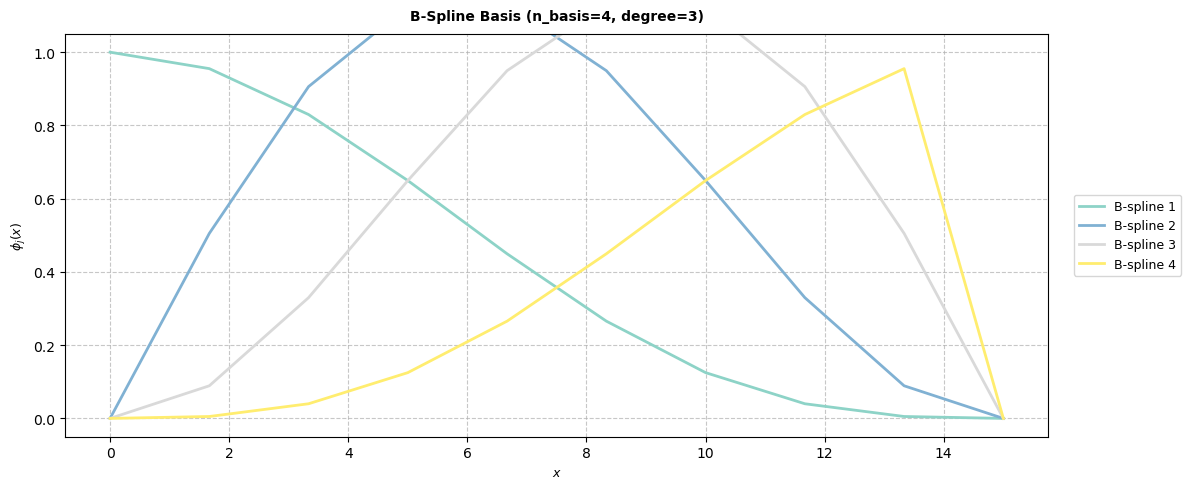


WEIGHT TYPE: HYPERBOLIC
----------------------------------------------------------------------------------------------------


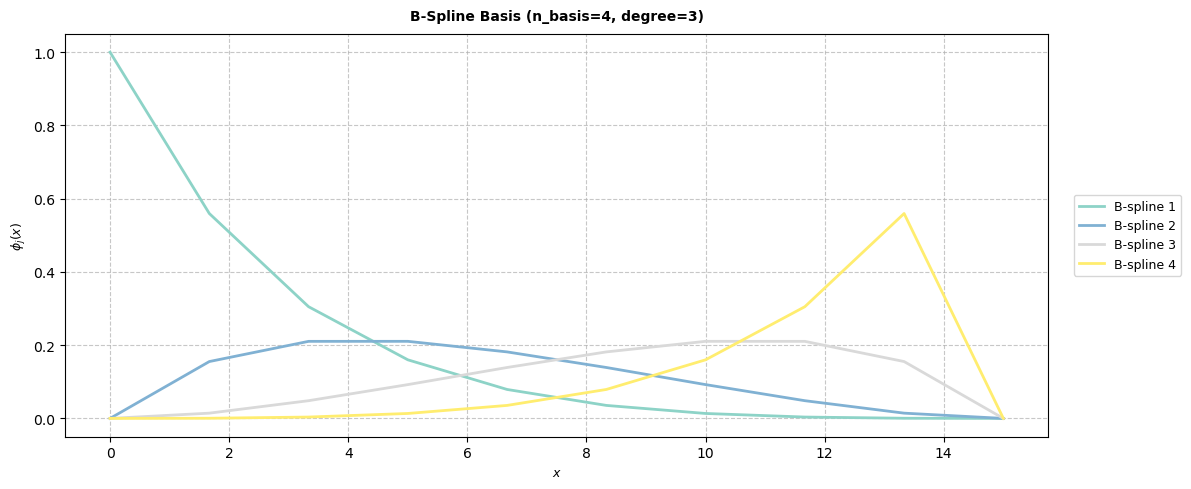


WEIGHT TYPE: VARIABLE_DEGREE
----------------------------------------------------------------------------------------------------


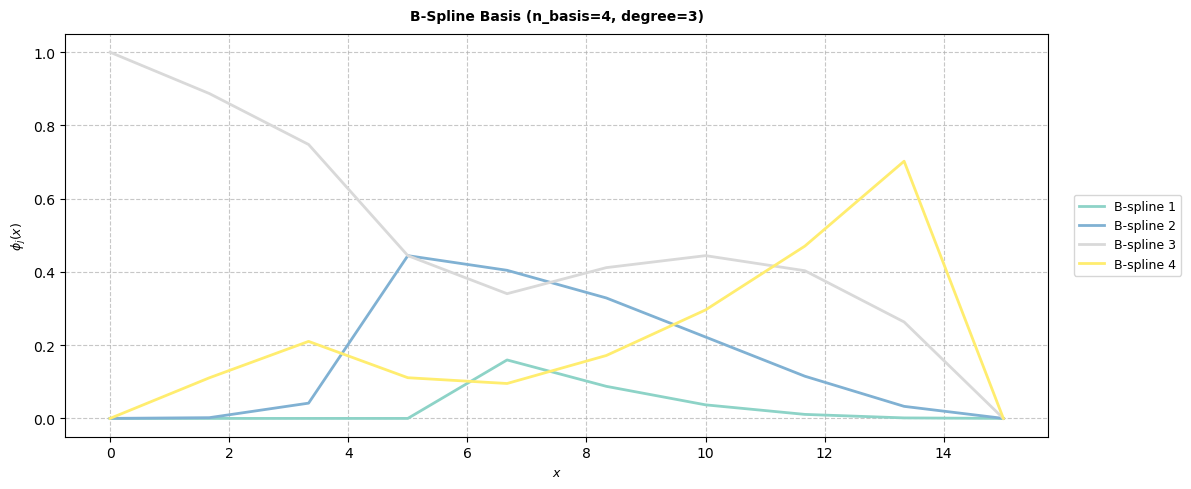

In [14]:

for weight_type in weight_type_list:

    print(f"\nWEIGHT TYPE: {weight_type.upper()}")
    print("-"*100)

    # 4. Initialize the basis class
    if weight_type == "variable_degree":
        p_func=smooth_sigmoid_degree_func
    else: 
        p_func=None
    basis = BSplineBasis(domain_range=domain, n_basis=n_basis, degree=degree, weight_type=weight_type, p_func=p_func)
    
    # 5. Create a plot of the B-splines
    basis.plot_b_spline(x_array)